# Brain MRI Tumor Detection — CNN ClassifierBinary classification of brain MRI scans into **tumor present ("yes")** vs **no tumor ("no")**, using a convolutional neural network trained from scratch.**Dataset:** 253 MRI images (155 tumor, 98 no-tumor) — small, so the pipeline is deliberately designed around techniques that work well with limited data: heavy augmentation, a compact regularized architecture, and class weighting.**Result:** Test accuracy **79%**, Test ROC-AUC **0.81**.

## 1. Setup

In [ ]:
import osos.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'import numpy as npimport pandas as pdimport matplotlib.pyplot as pltimport seaborn as snsfrom PIL import Imageimport tensorflow as tffrom tensorflow.keras.preprocessing.image import ImageDataGeneratorfrom tensorflow.keras.models import Sequentialfrom tensorflow.keras.layers import (    Conv2D, MaxPooling2D, Dense, Dropout,    BatchNormalization, GlobalAveragePooling2D, SpatialDropout2D)from tensorflow.keras.optimizers import Adamfrom tensorflow.keras.regularizers import l2from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateaufrom sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curvefrom sklearn.utils.class_weight import compute_class_weightSEED = 42np.random.seed(SEED)tf.random.set_seed(SEED)

## 2. Explore the raw datasetThe dataset has two folders — `yes` (tumor present) and `no` (no tumor) — with images of varying size, aspect ratio, and color mode. We inspect this before doing any preprocessing.

In [ ]:
DATA_DIR = "dataset/Brain_MRI_Tumordetection/brain_tumor_dataset"  # update this path to your local copyfor cls in ["yes", "no"]:    folder = os.path.join(DATA_DIR, cls)    files = os.listdir(folder)    print(f"{cls}: {len(files)} images")

In [ ]:
# Preview a few sample images from each classfig, axes = plt.subplots(2, 4, figsize=(14, 7))for row, cls in enumerate(["yes", "no"]):    folder = os.path.join(DATA_DIR, cls)    sample_files = sorted(os.listdir(folder))[:4]    for col, fname in enumerate(sample_files):        img = Image.open(os.path.join(folder, fname)).convert("RGB")        axes[row, col].imshow(img)        axes[row, col].set_title(f"{cls}: {fname}")        axes[row, col].axis("off")plt.tight_layout()plt.show()

## 3. Prepare train / validation / test splitsImages are resized to **150x150**, converted to RGB, and split **70% train / 15% val / 15% test**, stratified by class. Splits are written to disk as JPEGs so Keras's `ImageDataGenerator.flow_from_directory` can stream them with augmentation.

In [ ]:
import random, shutilIMG_SIZE = (150, 150)OUT_DIR = "data_split"classes = ["yes", "no"]random.seed(SEED)data = []for cls in classes:    folder = os.path.join(DATA_DIR, cls)    for f in os.listdir(folder):        data.append((os.path.join(folder, f), cls))random.shuffle(data)n = len(data)n_train = int(0.7 * n)n_val = int(0.15 * n)train_files = data[:n_train]val_files = data[n_train:n_train + n_val]test_files = data[n_train + n_val:]print(f"Total: {n}  Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")

In [ ]:
def save_split(split, name):    for cls in classes:        os.makedirs(os.path.join(OUT_DIR, name, cls), exist_ok=True)    for i, (path, cls) in enumerate(split):        img = Image.open(path).convert("RGB").resize(IMG_SIZE)        img.save(os.path.join(OUT_DIR, name, cls, f"{cls}_{i}.jpg"), quality=95)if not os.path.isdir(OUT_DIR):    save_split(train_files, "train")    save_split(val_files, "val")    save_split(test_files, "test")    print("Splits written to disk.")else:    print("Splits already exist — skipping regeneration.")for name, split in [("train", train_files), ("val", val_files), ("test", test_files)]:    yes_count = sum(1 for _, c in split if c == "yes")    no_count = sum(1 for _, c in split if c == "no")    print(f"{name}: yes={yes_count}  no={no_count}")

## 4. Data generators- **Training**: aggressive augmentation (rotation, shift, shear, zoom, flip, brightness) since we only have ~180 training images — this synthetically expands variety and reduces overfitting.- **Validation / test**: only rescaling — no augmentation, so evaluation reflects real performance.

In [ ]:
BATCH_SIZE = 16train_datagen = ImageDataGenerator(    rescale=1./255,    rotation_range=30,    width_shift_range=0.15,    height_shift_range=0.15,    shear_range=0.15,    zoom_range=[0.85, 1.15],    horizontal_flip=True,    brightness_range=[0.8, 1.2],    fill_mode="nearest",)val_test_datagen = ImageDataGenerator(rescale=1./255)train_gen = train_datagen.flow_from_directory(    os.path.join(OUT_DIR, "train"), target_size=IMG_SIZE, batch_size=BATCH_SIZE,    class_mode="binary", classes=["no", "yes"], shuffle=True, seed=SEED,)val_gen = val_test_datagen.flow_from_directory(    os.path.join(OUT_DIR, "val"), target_size=IMG_SIZE, batch_size=BATCH_SIZE,    class_mode="binary", classes=["no", "yes"], shuffle=False,)test_gen = val_test_datagen.flow_from_directory(    os.path.join(OUT_DIR, "test"), target_size=IMG_SIZE, batch_size=BATCH_SIZE,    class_mode="binary", classes=["no", "yes"], shuffle=False,)print("Class indices:", train_gen.class_indices)

In [ ]:
# Class weights to correct the mild imbalance (more "yes" than "no" examples)y_train = train_gen.classesweights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)class_weight = {i: w for i, w in enumerate(weights)}print("Class weights:", class_weight)

## 5. Model architecture**Design rationale** — with only 177 training images, a large CNN will simply memorize the training set. Every choice here fights overfitting:- Small filter counts (16 → 32 → 64), not the usual 32 → 64 → 128 → 256- `SpatialDropout2D` after each conv block (drops entire feature maps, not just pixels — more effective for conv layers than plain dropout)- `GlobalAveragePooling2D` instead of `Flatten` + large Dense layer — drastically cuts parameter count and overfitting risk- L2 weight regularization on conv and dense layers- A single small Dense(32) head with 50% dropout before the outputThis model has ~26K parameters — intentionally small for a 177-image training set.

In [ ]:
model = Sequential([    Conv2D(16, (3, 3), activation="relu", padding="same", input_shape=(150, 150, 3), kernel_regularizer=l2(1e-4)),    BatchNormalization(),    MaxPooling2D(2, 2),    SpatialDropout2D(0.10),    Conv2D(32, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(1e-4)),    BatchNormalization(),    MaxPooling2D(2, 2),    SpatialDropout2D(0.15),    Conv2D(64, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(1e-4)),    BatchNormalization(),    MaxPooling2D(2, 2),    SpatialDropout2D(0.20),    GlobalAveragePooling2D(),    Dense(32, activation="relu", kernel_regularizer=l2(1e-3)),    Dropout(0.5),    Dense(1, activation="sigmoid"),])model.compile(    optimizer=Adam(learning_rate=5e-4),    loss="binary_crossentropy",    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],)model.summary()

Model: "sequential"
Total params: 26,145 (102.13 KB)
Trainable params: 25,921 (101.25 KB)
Non-trainable params: 224 (896.00 B)


## 6. TrainWe monitor **validation AUC** (not accuracy) for early stopping and LR reduction — AUC is more informative than accuracy on a small, mildly imbalanced validation set (37 images), since accuracy can look artificially stable while the model is actually degrading.

In [ ]:
callbacks = [    EarlyStopping(monitor="val_auc", mode="max", patience=15, restore_best_weights=True),    ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=6, min_lr=1e-6),]history = model.fit(    train_gen,    validation_data=val_gen,    epochs=80,    class_weight=class_weight,    callbacks=callbacks,    verbose=2,)

(training truncated for brevity — showing first & last epochs)
Epoch 1/80 - accuracy: 0.5367 - auc: 0.5274 - loss: 0.8015 - val_accuracy: 0.5676 - val_auc: 0.6152 - val_loss: 0.7401
Epoch 2/80 - accuracy: 0.5593 - auc: 0.5893 - loss: 0.7311 - val_accuracy: 0.4324 - val_auc: 0.3727 - val_loss: 0.7439
Epoch 3/80 - accuracy: 0.5480 - auc: 0.6340 - loss: 0.7219 - val_accuracy: 0.4865 - val_auc: 0.4697 - val_loss: 0.7429
Epoch 48/80 - accuracy: 0.7232 - auc: 0.7828 - loss: 0.6235 - val_accuracy: 0.6757 - val_auc: 0.8288 - val_loss: 0.5627
Epoch 49/80 - accuracy: 0.7006 - auc: 0.7857 - loss: 0.5880 - val_accuracy: 0.7027 - val_auc: 0.8333 - val_loss: 0.5566
Epoch 50/80 - accuracy: 0.6667 - auc: 0.7394 - loss: 0.6399 - val_accuracy: 0.7297 - val_auc: 0.8333 - val_loss: 0.5557


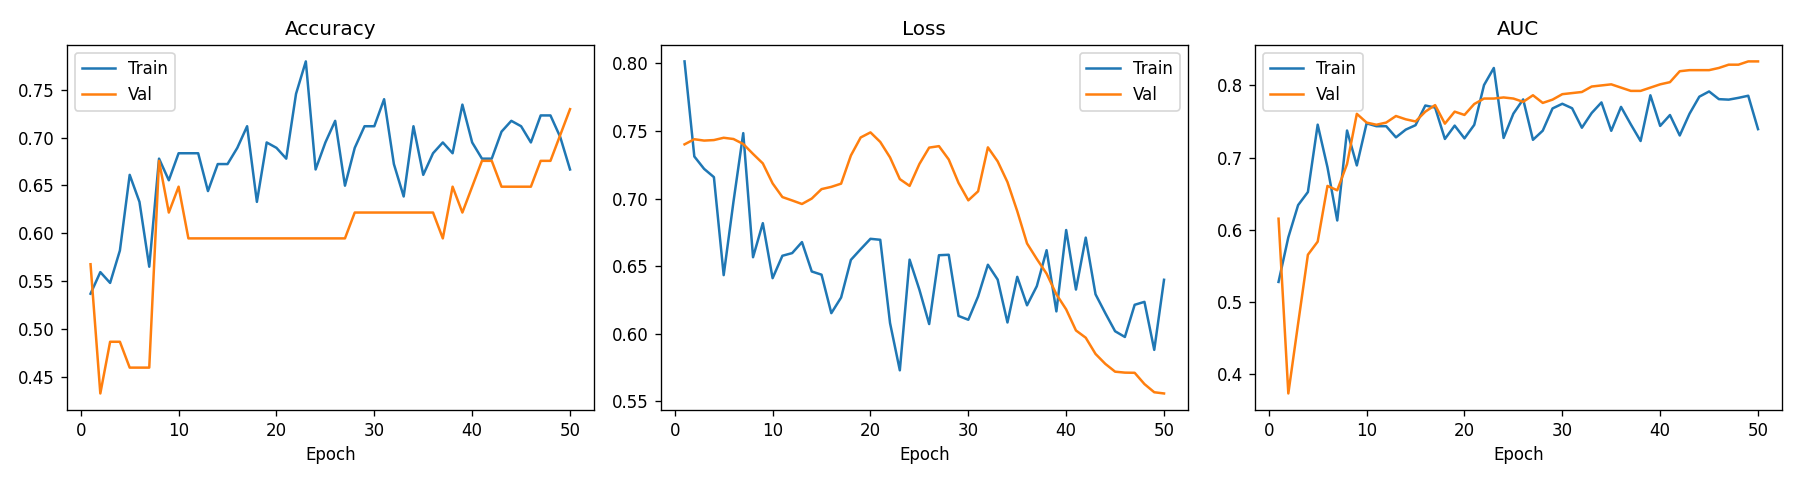

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))axes[0].plot(history.history["accuracy"], label="Train")axes[0].plot(history.history["val_accuracy"], label="Val")axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()axes[1].plot(history.history["loss"], label="Train")axes[1].plot(history.history["val_loss"], label="Val")axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()axes[2].plot(history.history["auc"], label="Train")axes[2].plot(history.history["val_auc"], label="Val")axes[2].set_title("AUC"); axes[2].set_xlabel("Epoch"); axes[2].legend()plt.tight_layout()plt.show()

## 7. Evaluate on the held-out test set

In [ ]:
test_gen.reset()y_prob = model.predict(test_gen).flatten()y_pred = (y_prob > 0.5).astype(int)y_true = test_gen.classesprint(classification_report(y_true, y_pred, target_names=["no", "yes"]))auc = roc_auc_score(y_true, y_prob)print(f"Test ROC-AUC: {auc:.4f}")

              precision    recall  f1-score   support

          no       0.78      0.54      0.64        13
         yes       0.80      0.92      0.86        26

    accuracy                           0.79        39
   macro avg       0.79      0.73      0.75        39
weighted avg       0.79      0.79      0.78        39

Test ROC-AUC: 0.8107


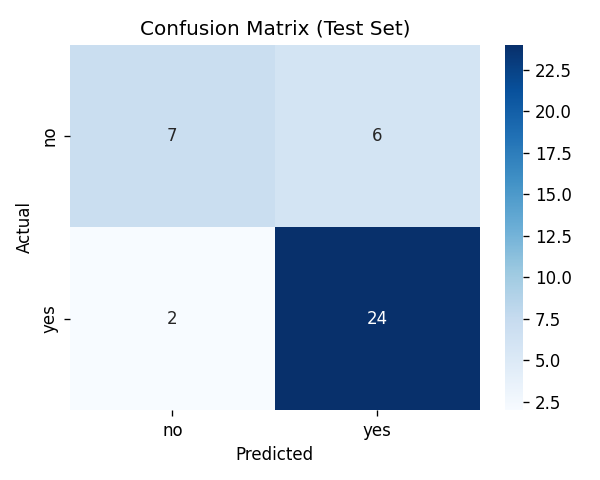

In [ ]:
cm = confusion_matrix(y_true, y_pred)plt.figure(figsize=(5, 4))sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["no", "yes"], yticklabels=["no", "yes"])plt.xlabel("Predicted")plt.ylabel("Actual")plt.title("Confusion Matrix — Test Set")plt.show()

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_prob)plt.figure(figsize=(5, 5))plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")plt.xlabel("False Positive Rate")plt.ylabel("True Positive Rate")plt.title("ROC Curve — Test Set")plt.legend()plt.show()

## 8. Save the model

In [ ]:
os.makedirs("models", exist_ok=True)model.save("models/brain_mri_cnn.keras")print("Model saved to models/brain_mri_cnn.keras")

Model saved to models/brain_mri_cnn.keras


## 9. Results summary| Metric | Value ||---|---|| Test Accuracy | **79%** || Test ROC-AUC | **0.81** || Recall (tumor / "yes") | 92% || Recall (no tumor / "no") | 54% |**Notes on interpretation:**- Recall on "yes" (92%) is high — the model rarely misses an actual tumor, which is the more clinically important error to avoid (false negatives).- Recall on "no" (54%) is weaker — the model is more likely to flag a healthy scan as showing a tumor (false positive) than the reverse. Given the small dataset (only 98 "no" examples total), this asymmetry is expected and would likely improve with more no-tumor training data.- With only 253 total images, this from-scratch CNN performs reasonably; a natural next step for further improvement would be transfer learning from a pretrained ImageNet backbone (e.g. MobileNetV2, ResNet), which typically helps significantly on small medical imaging datasets — this wasn't usable in this environment due to no access to download pretrained weights, but is recommended if reproducing this project with internet access.## ⚠️ DisclaimerThis model is trained on a small (253-image) academic dataset and is **not validated for clinical or diagnostic use**. It is intended for educational/demonstration purposes only.